# Wine Quality Prediction Lab 2
MLflow Experiment Tracking — Replication

## Step 1: Import Data

In [1]:
import os
os.chdir(r"C:\Users\sanja\OneDrive\Desktop\NEU\mlops\mlflow")
print(os.getcwd())

C:\Users\sanja\OneDrive\Desktop\NEU\mlops\mlflow


In [2]:
import pandas as pd

white_wine = pd.read_csv("data/winequality-white.csv", sep=";")
red_wine = pd.read_csv("data/winequality-red.csv", sep=",")

## Step 2: Explore Data

In [3]:
white_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [4]:
red_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Step 3: Data Preprocessing

In [5]:
red_wine['is_red'] = 1
white_wine['is_red'] = 0

data = pd.concat([red_wine, white_wine], axis=0)

# Remove spaces from column names
data.rename(columns=lambda x: x.replace(' ', '_'), inplace=True)

data.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,is_red
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


## Step 4: Data Visualization

C:\Users\sanja\AppData\Local\Temp\ipykernel_31820\3396162503.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data.quality, kde=False);


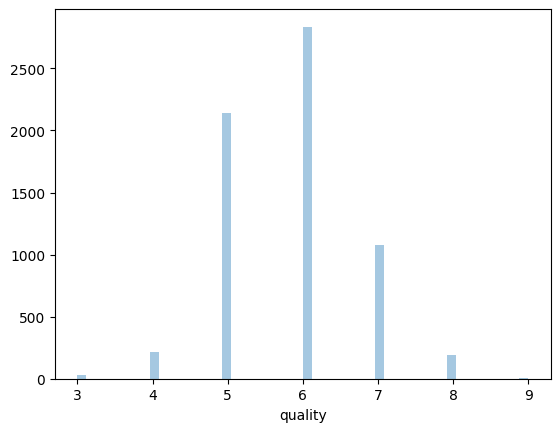

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.distplot(data.quality, kde=False);

## Step 5: Define High-Quality Wines

In [7]:
high_quality = (data.quality >= 7).astype(int)
data.quality = high_quality

## Step 6: Exploratory Data Analysis (EDA)

Box plots to identify potential predictors of wine quality.

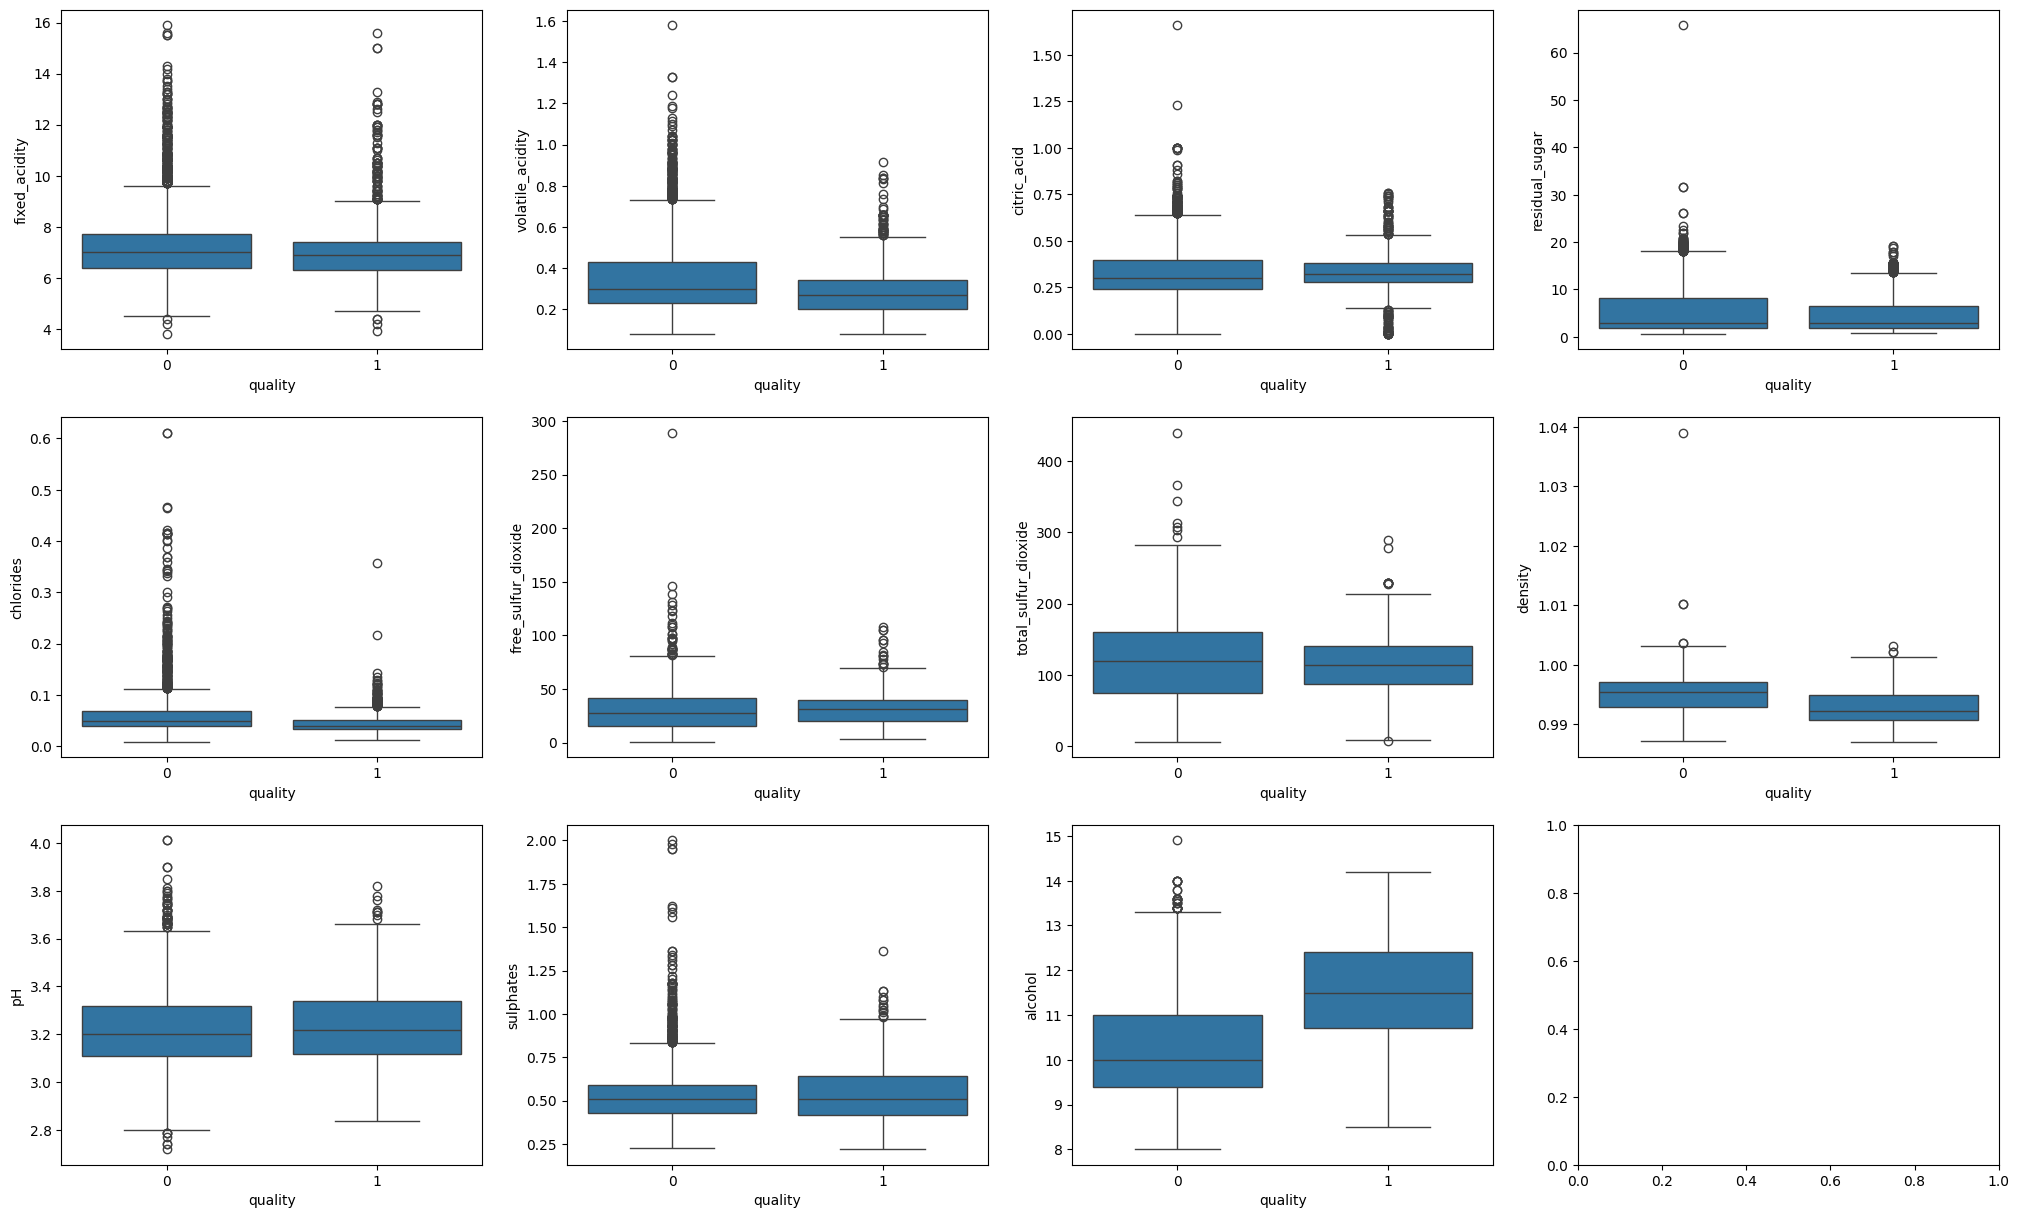

In [8]:
dims = (3, 4)

f, axes = plt.subplots(dims[0], dims[1], figsize=(25, 15))
axis_i, axis_j = 0, 0
for col in data.columns:
    if col == 'is_red' or col == 'quality':
        continue  # Box plots cannot be used on indicator variables
    sns.boxplot(x=high_quality, y=data[col], ax=axes[axis_i, axis_j])
    axis_j += 1
    if axis_j == dims[1]:
        axis_i += 1
        axis_j = 0

In the above box plots, a few variables stand out as good univariate predictors of quality.

- **Alcohol**: median alcohol content of high quality wines is greater than even the 75th quantile of low quality wines.
- **Density**: low quality wines have a greater density than high quality wines — inversely correlated with quality.

## Step 7: Check for Missing Data

In [9]:
data.isna().any()

fixed_acidity           False
volatile_acidity        False
citric_acid             False
residual_sugar          False
chlorides               False
free_sulfur_dioxide     False
total_sulfur_dioxide    False
density                 False
pH                      False
sulphates               False
alcohol                 False
quality                 False
is_red                  False
dtype: bool

## Step 8: Data Splitting

In [10]:
from sklearn.model_selection import train_test_split

X = data.drop(["quality"], axis=1)
y = data.quality

# Split out the training data
X_train, X_rem, y_train, y_rem = train_test_split(X, y, train_size=0.6, random_state=123)

# Split the remaining data equally into validation and test
X_val, X_test, y_val, y_test = train_test_split(X_rem, y_rem, test_size=0.5, random_state=123)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (3898, 12), Val: (1299, 12), Test: (1300, 12)


## Step 9: Build a Baseline Model (Random Forest)

Uses MLflow to track parameters and metrics.

In [11]:
import mlflow
import mlflow.pyfunc
import mlflow.sklearn
import numpy as np
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from mlflow.models.signature import infer_signature
from mlflow.utils.environment import _mlflow_conda_env
import cloudpickle
import time

# SklearnModelWrapper uses predict_proba instead of predict
# so we get class probabilities (needed for AUC)
class SklearnModelWrapper(mlflow.pyfunc.PythonModel):
    def __init__(self, model):
        self.model = model

    def predict(self, context, model_input):
        return self.model.predict_proba(model_input)[:, 1]


with mlflow.start_run(run_name='untuned_random_forest'):
    n_estimators = 10
    model = RandomForestClassifier(n_estimators=n_estimators, random_state=np.random.RandomState(123))
    model.fit(X_train, y_train)

    # predict_proba returns [prob_negative, prob_positive], slice with [:, 1]
    predictions_test = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, predictions_test)

    mlflow.log_param('n_estimators', n_estimators)
    mlflow.log_metric('auc', auc_score)

    wrappedModel = SklearnModelWrapper(model)
    signature = infer_signature(X_train, wrappedModel.predict(None, X_train))

    conda_env = _mlflow_conda_env(
        additional_conda_deps=None,
        additional_pip_deps=[
            "cloudpickle=={}".format(cloudpickle.__version__),
            "scikit-learn=={}".format(sklearn.__version__)
        ],
        additional_conda_channels=None,
    )
    mlflow.pyfunc.log_model(
        "random_forest_model",
        python_model=wrappedModel,
        conda_env=conda_env,
        signature=signature
    )

print(f"Baseline AUC: {auc_score}")

C:\Users\sanja\OneDrive\Desktop\NEU\mlops\mlflow\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\sanja\OneDrive\Desktop\NEU\mlops\mlflow\.venv\Lib\site-packages\mlflow\pyfunc\utils\data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
C:\Users\sanja\OneDrive\Desktop\NEU\mlops\mlflow\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforce

Baseline AUC: 0.8540300975814177


## Step 10: Feature Importance Analysis

In [12]:
feature_importances = pd.DataFrame(
    model.feature_importances_,
    index=X_train.columns.tolist(),
    columns=['importance']
)
feature_importances.sort_values('importance', ascending=False)

,importance
alcohol,0.160192
density,0.117415
volatile_acidity,0.093136
chlorides,0.086618
residual_sugar,0.082544
free_sulfur_dioxide,0.080473
pH,0.080212
total_sulfur_dioxide,0.077798
sulphates,0.075780
citric_acid,0.071857


## Step 11: Register Model in MLflow Model Registry

In [13]:
run_id = mlflow.search_runs(filter_string='tags.mlflow.runName = "untuned_random_forest"').iloc[0].run_id
print(f"Run ID: {run_id}")

Run ID: 89018dc63c3341beac6dd759847b3709


In [14]:
# If you see PERMISSION_DENIED: model already exists with name "wine_quality", use a different name
model_name = "wine_quality"
model_version = mlflow.register_model(f"runs:/{run_id}/random_forest_model", model_name)

# Registering takes a few seconds
time.sleep(15)

Registered model 'wine_quality' already exists. Creating a new version of this model...
2026/03/13 22:51:23 WARNING mlflow.tracking._model_registry.fluent: Run with id 89018dc63c3341beac6dd759847b3709 has no artifacts at artifact path 'random_forest_model', registering model based on models:/m-974f85259edc49b9a78b64e86a556de7 instead
Created version '4' of model 'wine_quality'.


## Step 12: Transition Model to Production

In [15]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

client.transition_model_version_stage(
    name=model_name,
    version=model_version.version,
    stage="Production",
)

C:\Users\sanja\AppData\Local\Temp\ipykernel_31820\136366179.py:5: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


<ModelVersion: aliases=[], creation_timestamp=1773456683982, current_stage='Production', deployment_job_state=None, description=None, last_updated_timestamp=1773456703370, metrics=None, model_id=None, name='wine_quality', params=None, run_id='89018dc63c3341beac6dd759847b3709', run_link=None, source='models:/m-974f85259edc49b9a78b64e86a556de7', status='READY', status_message=None, tags={}, user_id=None, version=4, workspace='default'>

## Step 13: Load Production Model and Evaluate

In [16]:
model = mlflow.pyfunc.load_model(f"models:/{model_name}/production")

# Sanity-check: should match the AUC logged by MLflow
print(f'AUC: {roc_auc_score(y_test, model.predict(X_test))}')

AUC: 0.8540300975814177


## Step 14 (Optional): Launch MLflow UI

Run in a separate terminal — do NOT run inside the notebook as it blocks execution:
```bash
mlflow ui --port=5001
```

## Step 15: Experiment with XGBoost + Hyperopt

Bayesian hyperparameter sweep using TPE. Each trial is logged as a **nested run** under `xgboost_models`.

In [17]:
from hyperopt import fmin, tpe, hp, SparkTrials, Trials, STATUS_OK
from hyperopt.pyll import scope
from math import exp
import mlflow.xgboost
import xgboost as xgb

search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'binary:logistic',
    'seed': 123,
}

In [18]:
def train_model(params):
    mlflow.xgboost.autolog()
    with mlflow.start_run(nested=True):
        train = xgb.DMatrix(data=X_train, label=y_train)
        validation = xgb.DMatrix(data=X_val, label=y_val)

        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=1000,
            evals=[(validation, "validation")],
            early_stopping_rounds=50
        )

        validation_predictions = booster.predict(validation)
        auc_score = roc_auc_score(y_val, validation_predictions)
        mlflow.log_metric('auc', auc_score)

        signature = infer_signature(X_train, booster.predict(train))
        mlflow.xgboost.log_model(booster, "model", signature=signature)

        # fmin minimizes, so negate AUC
        return {'status': STATUS_OK, 'loss': -1 * auc_score, 'booster': booster.attributes()}

In [20]:
print("Using regular Hyperopt Trials (no Spark required)")

Using regular Hyperopt Trials (no Spark required)


In [22]:
trials = Trials()

with mlflow.start_run(run_name='xgboost_models'):
    best_params = fmin(
        fn=train_model,
        space=search_space,
        algo=tpe.suggest,
        max_evals=10,
        trials=trials,
    )

  0%|                                 | 0/10 [00:00<?, ?trial/s, best loss=?]

2026/03/13 22:59:21 WARNING mlflow.utils.autologging_utils: MLflow xgboost autologging is known to be compatible with 2.1.0 <= xgboost, but the installed version is 1.7.6. If you encounter errors during autologging, try upgrading / downgrading xgboost to a compatible version, or try upgrading MLflow.



[0]	validation-logloss:0.54702                                               
[1]	validation-logloss:0.47304                                               
[2]	validation-logloss:0.42941                                               
[3]	validation-logloss:0.40121                                               
[4]	validation-logloss:0.38446                                               
[5]	validation-logloss:0.37144                                               
[6]	validation-logloss:0.36475                                               
[7]	validation-logloss:0.35761                                               
[8]	validation-logloss:0.35316                                               
[9]	validation-logloss:0.34974                                               
[10]	validation-logloss:0.34978                                              
[11]	validation-logloss:0.34834                                              
[12]	validation-logloss:0.34831                                 

2026/03/13 22:59:22 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\sanja\OneDrive\Desktop\NEU\mlops\mlflow\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."

2026/03/13 22:59:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.

C:\Users\sanja\OneD

 10%|▌     | 1/10 [00:14<02:10, 14.52s/trial, best loss: -0.8722156370745524]

...

 90%|█████▍| 9/10 [02:48<00:18, 18.65s/trial, best loss: -0.8964763473468698]

2026/03/13 23:02:10 WARNING mlflow.utils.autologging_utils: MLflow xgboost autologging is known to be compatible with 2.1.0 <= xgboost, but the installed version is 1.7.6. If you encounter errors during autologging, try upgrading / downgrading xgboost to a compatible version, or try upgrading MLflow.



[0]	validation-logloss:0.55934                                               
[1]	validation-logloss:0.48381                                               
[2]	validation-logloss:0.43635                                               
[3]	validation-logloss:0.40149                                               
[4]	validation-logloss:0.37654                                               
[5]	validation-logloss:0.36027                                               
[6]	validation-logloss:0.34577                                               
[7]	validation-logloss:0.34029                                               
[8]	validation-logloss:0.33633                                               
[9]	validation-logloss:0.33025                                               
[10]	validation-logloss:0.32945                                              
[11]	validation-logloss:0.32934                                              
[12]	validation-logloss:0.32768                                 

2026/03/13 23:02:11 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\sanja\OneDrive\Desktop\NEU\mlops\mlflow\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."

2026/03/13 23:02:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.

C:\Users\sanja\OneD

100%|█████| 10/10 [03:04<00:00, 18.48s/trial, best loss: -0.8964763473468698]


## Step 16: Find Best XGBoost Run

In [23]:
best_run = mlflow.search_runs(order_by=['metrics.auc DESC']).iloc[0]
print(f'AUC of Best Run: {best_run["metrics.auc"]}')

AUC of Best Run: 0.8964763473468698


## Step 17: Register Best XGBoost Model and Promote to Production

In [24]:
new_model_version = mlflow.register_model(f"runs:/{best_run.run_id}/model", model_name)

time.sleep(10)

Registered model 'wine_quality' already exists. Creating a new version of this model...
2026/03/13 23:02:36 WARNING mlflow.tracking._model_registry.fluent: Run with id 36097d9ade2d4540acb84e678f49d981 has no artifacts at artifact path 'model', registering model based on models:/m-bc7d8a52bf664647b45aea34b6b77948 instead
Created version '5' of model 'wine_quality'.


In [25]:
# Archive old RF model version, promote new XGBoost version
client.transition_model_version_stage(
    name=model_name,
    version=model_version.version,
    stage='Archived'
)

client.transition_model_version_stage(
    name=model_name,
    version=new_model_version.version,
    stage='Production'
)

C:\Users\sanja\AppData\Local\Temp\ipykernel_31820\2972321032.py:2: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(
C:\Users\sanja\AppData\Local\Temp\ipykernel_31820\2972321032.py:8: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


<ModelVersion: aliases=[], creation_timestamp=1773457356612, current_stage='Production', deployment_job_state=None, description=None, last_updated_timestamp=1773457371007, metrics=None, model_id=None, name='wine_quality', params=None, run_id='36097d9ade2d4540acb84e678f49d981', run_link=None, source='models:/m-bc7d8a52bf664647b45aea34b6b77948', status='READY', status_message=None, tags={}, user_id=None, version=5, workspace='default'>

## Step 18: Evaluate New Production Model

In [26]:
model = mlflow.pyfunc.load_model(f"models:/{model_name}/production")
print(f"AUC: {roc_auc_score(y_test, model.predict(X_test))}")

AUC: 0.8982653855363985


## Step 19: Batch Inference via Spark UDF

In [28]:
model = mlflow.pyfunc.load_model(f"models:/{model_name}/production")
batch_predictions = model.predict(X_test)
print(batch_predictions[:10])

[0.00129354 0.01970387 0.0921462  0.18757123 0.08040955 0.01819243
 0.009364   0.55913925 0.02040914 0.06101219]


In [29]:
print(f"Total predictions: {len(batch_predictions)}")

Total predictions: 1300


## Step 20: Real-Time Inference

First, serve the model in a **separate terminal** (after activating your venv):
```bash
mlflow models serve --env-manager=local -m models:/wine_quality/production -h 0.0.0.0 -p 5001
```
Then run the cell below.

In [30]:
import requests
import json

url = 'http://localhost:5001/invocations'

data_dict = {"dataframe_split": X_test.to_dict(orient='split')}

response = requests.post(url, json=data_dict)
predictions = response.json()

print(predictions)

{'predictions': [0.0012935447739437222, 0.019703874364495277, 0.09214620292186737, 0.1875712275505066, 0.08040954917669296, 0.01819242537021637, 0.00936400331556797, 0.5591392517089844, 0.02040913514792919, 0.06101218983530998, 0.010970896109938622, 0.002142817946150899, 0.014042392373085022, 0.08015435934066772, 0.001818712567910552, 0.0794067308306694, 0.015017850324511528, 0.44929686188697815, 0.5296186804771423, 0.042429424822330475, 0.12933719158172607, 0.9458868503570557, 0.01671551540493965, 0.005418998654931784, 0.00046829416533000767, 0.0063273417763412, 0.0030035076197236776, 0.006840103305876255, 0.7954902052879333, 0.003376970300450921, 0.004232099745422602, 0.024270212277770042, 0.017769625410437584, 0.0032684635370969772, 0.001526056556031108, 0.1761595755815506, 0.6500893831253052, 0.00031925318762660027, 0.0011195051483809948, 0.0008605828625150025, 0.0009968156227841973, 0.20438151061534882, 0.0014691029209643602, 0.005648809485137463, 0.0031229639425873756, 0.00100097

## Feature 1 & 2: LightGBM and Logistic Regression Models
### Step 21: Install LightGBM

In [31]:
import subprocess
subprocess.run(["pip", "install", "lightgbm"], check=True)

CompletedProcess(args=['pip', 'install', 'lightgbm'], returncode=0)

## Step 22: Import Additional Libraries

In [32]:
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import mlflow

## Step 23: Train and Log LightGBM Model with Extended Metrics and Confusion Matrix

In [34]:
with mlflow.start_run(run_name='lightgbm_model'):
    lgb_model = lgb.LGBMClassifier(n_estimators=100, random_state=123)
    lgb_model.fit(X_train, y_train)
    
    lgb_preds_proba = lgb_model.predict_proba(X_test)[:, 1]
    lgb_preds = lgb_model.predict(X_test)
    
    # log params
    mlflow.log_param('n_estimators', 100)
    mlflow.log_param('model_type', 'lightgbm')
    
    # log metrics
    mlflow.log_metric('auc', roc_auc_score(y_test, lgb_preds_proba))
    mlflow.log_metric('precision', precision_score(y_test, lgb_preds))
    mlflow.log_metric('recall', recall_score(y_test, lgb_preds))
    mlflow.log_metric('f1', f1_score(y_test, lgb_preds))
    
    # log confusion matrix as artifact
    fig, ax = plt.subplots()
    cm = confusion_matrix(y_test, lgb_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax)
    ax.set_title("LightGBM Confusion Matrix")
    mlflow.log_figure(fig, "confusion_matrix_lightgbm.png")
    plt.close()
    
    # log model
    mlflow.sklearn.log_model(lgb_model, "lightgbm_model")
    
    print(f"LightGBM AUC: {roc_auc_score(y_test, lgb_preds_proba):.4f}")
    print(f"Precision: {precision_score(y_test, lgb_preds):.4f}")
    print(f"Recall: {recall_score(y_test, lgb_preds):.4f}")
    print(f"F1: {f1_score(y_test, lgb_preds):.4f}")

[LightGBM] [Info] Number of positive: 774, number of negative: 3124
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000572 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1475
[LightGBM] [Info] Number of data points in the train set: 3898, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.198563 -> initscore=-1.395298
[LightGBM] [Info] Start training from score -1.395298


2026/03/13 23:13:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/13 23:13:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LightGBM AUC: 0.8978
Precision: 0.7448
Recall: 0.5586
F1: 0.6384


## Step 24: Train and Log Logistic Regression Model with Extended Metrics and Confusion Matrix

In [36]:
with mlflow.start_run(run_name='logistic_regression_model'):
    lr_model = LogisticRegression(max_iter=1000, random_state=123)
    lr_model.fit(X_train, y_train)
    
    lr_preds_proba = lr_model.predict_proba(X_test)[:, 1]
    lr_preds = lr_model.predict(X_test)
    
    # log params
    mlflow.log_param('max_iter', 1000)
    mlflow.log_param('model_type', 'logistic_regression')
    
    # log metrics
    mlflow.log_metric('auc', roc_auc_score(y_test, lr_preds_proba))
    mlflow.log_metric('precision', precision_score(y_test, lr_preds))
    mlflow.log_metric('recall', recall_score(y_test, lr_preds))
    mlflow.log_metric('f1', f1_score(y_test, lr_preds))
    
    # log confusion matrix as artifact
    fig, ax = plt.subplots()
    cm = confusion_matrix(y_test, lr_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax)
    ax.set_title("Logistic Regression Confusion Matrix")
    mlflow.log_figure(fig, "confusion_matrix_lr.png")
    plt.close()
    
    # log model
    mlflow.sklearn.log_model(lr_model, "logistic_regression_model")
    
    print(f"Logistic Regression AUC: {roc_auc_score(y_test, lr_preds_proba):.4f}")
    print(f"Precision: {precision_score(y_test, lr_preds):.4f}")
    print(f"Recall: {recall_score(y_test, lr_preds):.4f}")
    print(f"F1: {f1_score(y_test, lr_preds):.4f}")

C:\Users\sanja\OneDrive\Desktop\NEU\mlops\mlflow\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
2026/03/13 23:15:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/13 23:15:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recomm

Logistic Regression AUC: 0.8122
Precision: 0.6628
Recall: 0.2227
F1: 0.3333


## Feature 3 & 4: Model Comparison
### Step 25: Compare All Models

In [37]:
import pandas as pd

results = mlflow.search_runs(order_by=['metrics.auc DESC'])
comparison = results[['tags.mlflow.runName', 'metrics.auc', 'metrics.precision', 'metrics.recall', 'metrics.f1']].dropna()
comparison.columns = ['Model', 'AUC', 'Precision', 'Recall', 'F1']
print(comparison.to_string(index=False))

                    Model      AUC  Precision   Recall       F1
           lightgbm_model 0.897846   0.744792 0.558594 0.638393
logistic_regression_model 0.812246   0.662791 0.222656 0.333333
